In [2]:
# =============================
# 📦 Step 1: Import Libraries
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =============================
# 📂 Step 2: Load the Dataset
# =============================
# Example dataset (replace with your Kaggle CSV path)
df = pd.read_csv(r"C:\Users\amans\Downloads\Energy_consumption_dataset.csv")

# Display first few rows
df.head()


,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732


In [31]:
# =============================
# 🧹 Step 3: Data Preprocessing
# =============================

# No need to drop anything unless required
# (but if you had date/time columns, drop them here)

# Check for null values
print("Null values in each column:")
print(df.isnull().sum())

# ✅ Correct feature and target split
X = df.drop('energyconsumption', axis=1)   # Independent variables
y = df['energyconsumption']                # Target variable

# ✅ Split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n✅ Data Preprocessing Done Successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Null values in each column:
month                0
hour                 0
dayofweek            0
holiday              0
temperature          0
humidity             0
squarefootage        0
occupancy            0
hvacusage            0
lightingusage        0
renewableenergy      0
energyconsumption    0
dtype: int64

✅ Data Preprocessing Done Successfully!
Training samples: 4000
Testing samples: 1000


In [34]:
# =============================
# 🤖 Step 4: Train the Models
# =============================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ✅ Step 4.1: Handle Missing Values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# ✅ Step 4.2: Encode Non-Numeric Columns (if any)
# Convert categorical data to numeric (One-Hot Encoding)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align both datasets (ensure same columns)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ✅ Step 4.3: Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# ✅ Step 4.4: Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("✅ Models Trained Successfully!")

# ✅ Step 4.5: Evaluate Model Performance
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📊 {model_name} Performance:")
    print("R² Score:", r2_score(y_true, y_pred))
    print("Mean Absolute Error:", mean_absolute_error(y_true, y_pred))
    print("Mean Squared Error:", mean_squared_error(y_true, y_pred))

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")


✅ Models Trained Successfully!

📊 Linear Regression Performance:
R² Score: 0.26936592356273825
Mean Absolute Error: 6.1573822319593186
Mean Squared Error: 60.98224032839963

📊 Random Forest Regressor Performance:
R² Score: 0.23886414267848677
Mean Absolute Error: 6.334920928857565
Mean Squared Error: 63.52806592333727


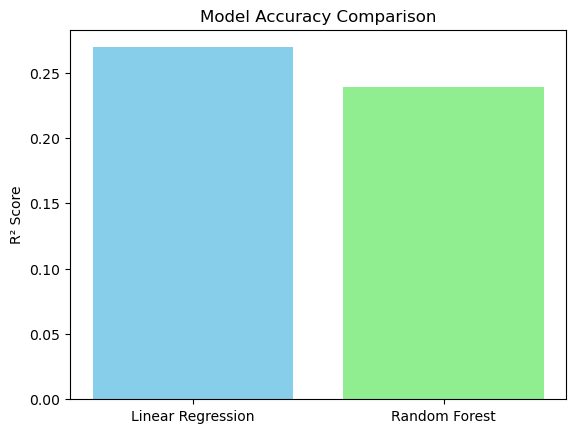

In [37]:
# =============================
# 📊 Step 6: Compare Performance
# =============================
models = ['Linear Regression', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, r2_scores, color=['skyblue', 'lightgreen'])
plt.ylabel("R² Score")
plt.title("Model Accuracy Comparison")
plt.show()


In [38]:
# =============================
# 📉 Step 7: Predict Future Values (Example)
# =============================
# You can use Random Forest (better accuracy) for final prediction
sample = X_test.iloc[0:1]
predicted_value = rf.predict(sample)
print("Predicted Energy Consumption:", predicted_value[0])


Predicted Energy Consumption: 74.72108049921981


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


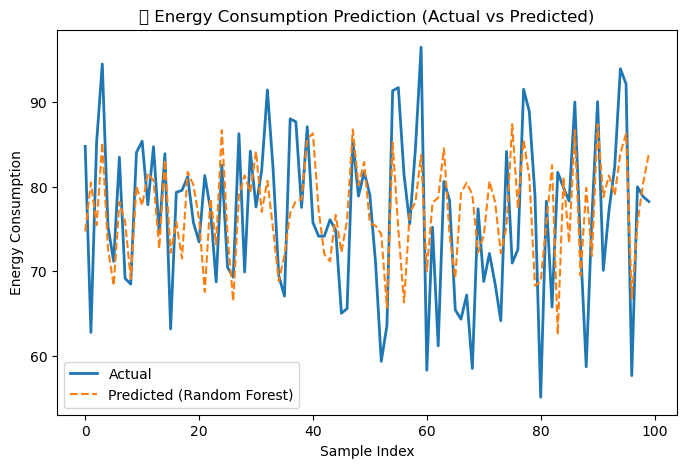


✅ Project Completed Successfully!


In [39]:
# =============================
# 📈 Step 8: Visualization
# =============================

plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label='Actual', linewidth=2)
plt.plot(y_pred_rf[:100], label='Predicted (Random Forest)', linestyle='dashed')
plt.title("🔋 Energy Consumption Prediction (Actual vs Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

print("\n✅ Project Completed Successfully!")